In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

In [2]:
df = pd.read_csv('../../../data/fully combined/wr_all_weeks.csv')
print(f'Shape: {df.shape}')
print(f'Sezone: {df["season"].min()} – {df["season"].max()}')
df.head()

Shape: (46115, 99)
Sezone: 2015 – 2025


,game_id,receiver_player_id,receiver_player_name,passer_player_id,defteam,targets,receptions,receiving_yards,air_yards,yac,tds,epa,wpa,avg_depth,catch_rate,posteam,team_pass_attempts,team_air_yards,team_epa,air_yard_share,target_share,yards_per_target,def_targets_dev,def_receptions_dev,def_yards_dev,...,targets_Q4,lost_yards_due_to_penalty,yards_wp_<25,yards_wp_25_45,yards_wp_45_55,yards_wp_55_75,yards_wp_>75,yards_wp_NA,receptions_wp_<25,receptions_wp_25_45,receptions_wp_45_55,receptions_wp_55_75,receptions_wp_>75,receptions_wp_NA,targets_wp_<25,targets_wp_25_45,targets_wp_45_55,targets_wp_55_75,targets_wp_>75,targets_wp_NA,home_team,away_team,pregame_spread,pregame_total,season
0,2015_01_BAL_DEN,00-0020337,S.Smith,00-0026158,10,7.0,2.0,13.0,60.0,7.0,0.0,-10.770362,-0.462443,8.571429,0.285714,3,32.0,192.0,-13.765043,0.312500,0.21875,1.857143,1.044305,0.967226,0.904681,...,3.0,0.0,0.0,13.0,0.0,0.0,0.0,0,0.0,2.0,0.0,0.0,0.0,0,0,5,0,2,0,0,10,3,4.5,46.5,2015
1,2015_01_BAL_DEN,00-0024313,O.Daniels,00-0010346,3,2.0,2.0,5.0,2.0,3.0,0.0,-0.248920,-0.006820,1.000000,1.000000,3,32.0,192.0,-13.765043,0.010417,0.06250,2.500000,0.959631,0.973374,0.957703,...,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0,0.0,0.0,0.0,0.0,2.0,0,0,0,0,0,2,0,10,3,4.5,46.5,2015
2,2015_01_BAL_DEN,00-0026237,A.Caldwell,00-0010346,3,1.0,1.0,1.0,0.0,1.0,0.0,-0.664543,-0.022189,0.000000,1.000000,3,32.0,192.0,-13.765043,0.000000,0.03125,1.000000,0.959631,0.973374,0.957703,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0.0,0.0,0.0,0.0,1.0,0,0,0,0,0,1,0,10,3,4.5,46.5,2015
3,2015_01_BAL_DEN,00-0026373,J.Forsett,00-0026158,10,7.0,4.0,13.0,5.0,13.0,0.0,-1.504406,-0.141163,0.714286,0.571429,3,32.0,192.0,-13.765043,0.026042,0.21875,1.857143,1.044305,0.967226,0.904681,...,3.0,0.0,6.0,0.0,0.0,7.0,0.0,0,3.0,0.0,0.0,1.0,0.0,0,4,2,0,1,0,0,10,3,4.5,46.5,2015
4,2015_01_BAL_DEN,00-0026739,J.Norwood,00-0010346,3,5.0,2.0,25.0,50.0,7.0,0.0,-5.110127,-0.168977,10.000000,0.400000,3,32.0,192.0,-13.765043,0.260417,0.15625,5.000000,0.959631,0.973374,0.957703,...,0.0,0.0,0.0,0.0,0.0,25.0,0.0,0,0.0,0.0,0.0,2.0,0.0,0,0,0,0,2,3,0,10,3,4.5,46.5,2015


In [3]:
df.dtypes.to_frame('dtype').reset_index().rename(columns={'index': 'column'})

,column,dtype
0,game_id,object
1,receiver_player_id,object
2,receiver_player_name,object
3,passer_player_id,object
4,defteam,int64
...,...,...
94,home_team,int64
95,away_team,int64
96,pregame_spread,float64
97,pregame_total,float64


In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct


In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
defteam,46115.0,15.965998,9.628853,0.0,8.0,16.0,25.0,32.0
targets,46115.0,4.020362,3.131419,1.0,1.0,3.0,6.0,23.0
receptions,46115.0,2.656554,2.268011,0.0,1.0,2.0,4.0,18.0
receiving_yards,46115.0,29.642047,31.758577,-17.0,7.0,19.0,43.0,300.0
air_yards,46115.0,32.209845,40.914385,-92.0,3.0,17.0,50.0,334.0
...,...,...,...,...,...,...,...,...
home_team,46115.0,15.959861,9.619081,0.0,8.0,16.0,25.0,32.0
away_team,46115.0,15.971831,9.620773,0.0,8.0,16.0,24.0,32.0
pregame_spread,46115.0,1.890914,5.962851,-18.0,-3.0,3.0,6.0,22.0
pregame_total,46115.0,45.339640,4.338047,28.5,42.5,45.0,48.0,63.5


In [22]:
df.groupby('season').size().rename('zapisi').reset_index()

,season,zapisi
0,2015,4314
1,2016,4308
2,2017,4332
3,2018,4304
4,2019,4274
5,2020,4435
6,2021,4616
7,2022,4550
8,2023,4599
9,2024,4465


In [23]:
df['week'] = df['game_id'].str.split('_').str[1].astype(int)
print('Weeks:', sorted(df['week'].unique()))
df.groupby('week').size().rename('zapisi').reset_index()

Weeks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]


,week,zapisi
0,1,2780
1,2,2826
2,3,2820
3,4,2748
4,5,2566
5,6,2542
6,7,2536
7,8,2569
8,9,2219
9,10,2224


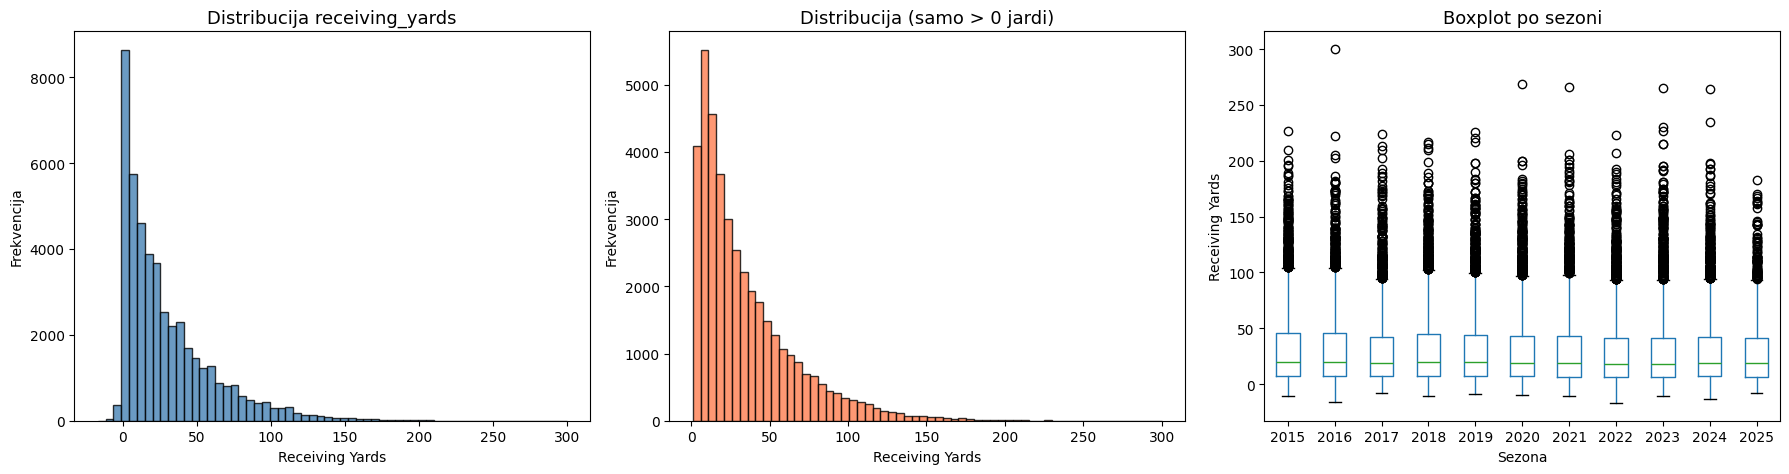

=== Opisna statistika receiving_yards ===
count    46115.00
mean        29.64
std         31.76
min        -17.00
25%          7.00
50%         19.00
75%         43.00
max        300.00
Name: receiving_yards, dtype: float64

Igrači s 0 jardi:        5509  (11.9%)
Igrači s > 100 jardi:    1925  (4.2%)
Igrači s > 150 jardi:     309  (0.7%)


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['receiving_yards'], bins=60, edgecolor='black', color='steelblue', alpha=0.8)
axes[0].set_title('Distribucija receiving_yards', fontsize=13)
axes[0].set_xlabel('Receiving Yards')
axes[0].set_ylabel('Frekvencija')

# Log skala (zbog dugog repa)
axes[1].hist(df['receiving_yards'][df['receiving_yards'] > 0], bins=60,
             edgecolor='black', color='coral', alpha=0.8)
axes[1].set_title('Distribucija (samo > 0 jardi)', fontsize=13)
axes[1].set_xlabel('Receiving Yards')
axes[1].set_ylabel('Frekvencija')

# Boxplot po sezoni
df.boxplot(column='receiving_yards', by='season', ax=axes[2], grid=False)
axes[2].set_title('Boxplot po sezoni', fontsize=13)
axes[2].set_xlabel('Sezona')
axes[2].set_ylabel('Receiving Yards')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("=== Opisna statistika receiving_yards ===")
print(df['receiving_yards'].describe().round(2))
print(f"\nIgrači s 0 jardi:      {(df['receiving_yards'] == 0).sum():>6}  ({(df['receiving_yards'] == 0).mean()*100:.1f}%)")
print(f"Igrači s > 100 jardi:  {(df['receiving_yards'] > 100).sum():>6}  ({(df['receiving_yards'] > 100).mean()*100:.1f}%)")
print(f"Igrači s > 150 jardi:  {(df['receiving_yards'] > 150).sum():>6}  ({(df['receiving_yards'] > 150).mean()*100:.1f}%)")

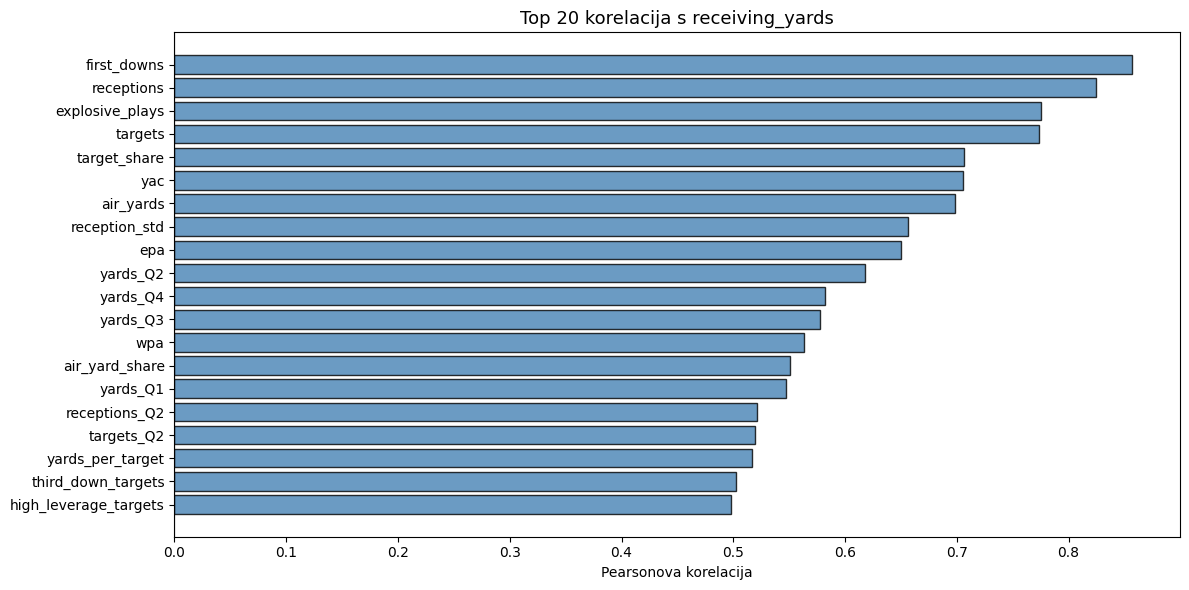


Top 20 korelacija (apsolutno):
                       |korelacija|  korelacija
first_downs                   0.857         NaN
receptions                    0.824       0.824
explosive_plays               0.775         NaN
targets                       0.773       0.773
target_share                  0.706       0.706
yac                           0.705       0.705
air_yards                     0.698       0.698
reception_std                 0.656         NaN
epa                           0.650       0.650
yards_Q2                      0.618         NaN
yards_Q4                      0.582         NaN
yards_Q3                      0.578         NaN
wpa                           0.563       0.563
air_yard_share                0.551       0.551
yards_Q1                      0.548         NaN
receptions_Q2                 0.521         NaN
targets_Q2                    0.520         NaN
yards_per_target              0.517       0.517
third_down_targets            0.503         NaN
high_lev

In [25]:
# Korelacija svih numeričkih featuresa s receiving_yards (sortirano po apsolutnoj vrijednosti)
numeric_df = df.select_dtypes(include='number')
corr_target = numeric_df.corr()['receiving_yards'].drop('receiving_yards')
corr_sorted = corr_target.abs().sort_values(ascending=False)

top_20 = corr_sorted.head(20).index
corr_top20 = corr_target[top_20]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['steelblue' if v > 0 else 'coral' for v in corr_top20.values]
ax.barh(top_20[::-1], corr_top20[top_20[::-1]].values, color=colors[::-1], edgecolor='black', alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 korelacija s receiving_yards', fontsize=13)
ax.set_xlabel('Pearsonova korelacija')
plt.tight_layout()
plt.show()

print("\nTop 20 korelacija (apsolutno):")
print(corr_sorted.head(20).round(3).to_frame('|korelacija|').join(corr_target.head(20).round(3).to_frame('korelacija')))

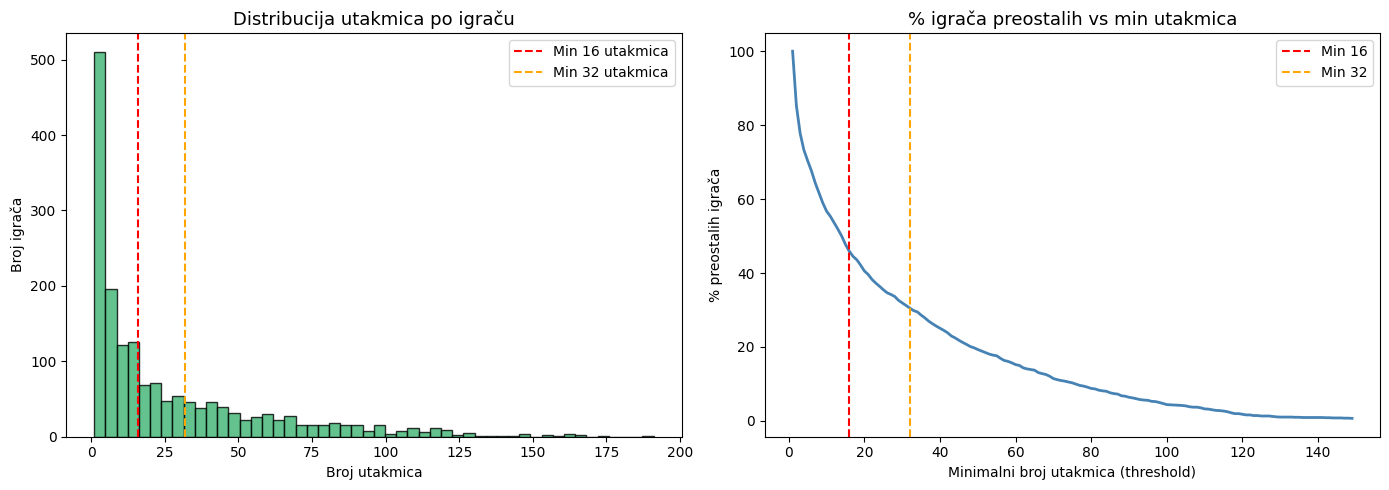

Ukupno jedinstvenih igrača:          1719
Igrači s >= 3 utakmica:              1337
Igrači s >= 5 utakmica:              1209
Igrači s >= 8 utakmica:              1059
Igrači s >= 16 utakmica:              789
Igrači s >= 32 utakmica:              525
Igrači s >= 64 utakmica:              239

Prosjek utakmica po igraču:         26.8
Medijan utakmica po igraču:         13.0


In [26]:
# Distribucija broja utakmica po igraču
games_per_player = df.groupby('receiver_player_id').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(games_per_player, bins=50, edgecolor='black', color='mediumseagreen', alpha=0.8)
axes[0].axvline(16, color='red', linestyle='--', label='Min 16 utakmica')
axes[0].axvline(32, color='orange', linestyle='--', label='Min 32 utakmica')
axes[0].set_title('Distribucija utakmica po igraču', fontsize=13)
axes[0].set_xlabel('Broj utakmica')
axes[0].set_ylabel('Broj igrača')
axes[0].legend()

# Kumulativni % igrača vs min utakmica
thresholds = range(1, 150)
pct_remaining = [100 * (games_per_player >= t).sum() / len(games_per_player) for t in thresholds]
axes[1].plot(list(thresholds), pct_remaining, color='steelblue', linewidth=2)
axes[1].axvline(16, color='red', linestyle='--', label='Min 16')
axes[1].axvline(32, color='orange', linestyle='--', label='Min 32')
axes[1].set_title('% igrača preostalih vs min utakmica', fontsize=13)
axes[1].set_xlabel('Minimalni broj utakmica (threshold)')
axes[1].set_ylabel('% preostalih igrača')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Ukupno jedinstvenih igrača:         {df['receiver_player_id'].nunique():>5}")
print(f"Igrači s >= 3 utakmica:             {(games_per_player >= 3).sum():>5}")
print(f"Igrači s >= 5 utakmica:             {(games_per_player >= 5).sum():>5}")
print(f"Igrači s >= 8 utakmica:             {(games_per_player >= 8).sum():>5}")
print(f"Igrači s >= 16 utakmica:            {(games_per_player >= 16).sum():>5}")
print(f"Igrači s >= 32 utakmica:            {(games_per_player >= 32).sum():>5}")
print(f"Igrači s >= 64 utakmica:            {(games_per_player >= 64).sum():>5}")
print(f"\nProsjek utakmica po igraču:         {games_per_player.mean():.1f}")
print(f"Medijan utakmica po igraču:         {games_per_player.median():.1f}")

In [27]:
from sklearn.preprocessing import StandardScaler

# 1) Sortiranje po igraču i vremenu
df_model = df.copy()
df_model['week'] = df_model['game_id'].str.split('_').str[1].astype(int)
df_model = df_model.sort_values(['receiver_player_id', 'season', 'week', 'game_id']).reset_index(drop=True)

# 2) Log transformacija ciljne varijable
df_model['target_yards'] = df_model['receiving_yards'].astype(float)
negative_yards_count = int((df_model['target_yards'] < 0).sum())

# Za log1p, negativne jardove mapiramo na 0 da izbegnemo invalidne vrednosti
df_model['target_yards_for_log'] = df_model['target_yards'].clip(lower=0)
df_model['target_yards_log'] = np.log1p(df_model['target_yards_for_log'])

print('Cell 1/4 gotova: sortiranje + log target')
print(f'Negativnih receiving_yards (clip na 0 pre log): {negative_yards_count}')

Cell 1/4 gotova: sortiranje + log target
Negativnih receiving_yards (clip na 0 pre log): 618


In [28]:
# 3) Strogo vremensko deljenje (bez random split-a)
df_model['time_key'] = df_model['season'].astype(int) * 100 + df_model['week'].astype(int)
unique_time_keys = np.array(sorted(df_model['time_key'].unique()))

n_time = len(unique_time_keys)
train_end = int(n_time * 0.70)
val_end = int(n_time * 0.85)

train_keys = unique_time_keys[:train_end]
val_keys = unique_time_keys[train_end:val_end]
test_keys = unique_time_keys[val_end:]

train_mask = df_model['time_key'].isin(train_keys)
val_mask = df_model['time_key'].isin(val_keys)
test_mask = df_model['time_key'].isin(test_keys)

print('Cell 2/4 gotova: time split')
print(f'Ukupno vremenskih koraka: {n_time}')
print(f'Train keys: {len(train_keys)} | Val keys: {len(val_keys)} | Test keys: {len(test_keys)}')

Cell 2/4 gotova: time split
Ukupno vremenskih koraka: 222
Train keys: 155 | Val keys: 33 | Test keys: 34


In [29]:
# 4) Feature set (izbacujemo ID kolone, target i leakage kolone)
exclude_cols = {
    'receiving_yards',
    'target_yards',
    'target_yards_for_log',
    'target_yards_log',
    'game_id',
    'receiver_player_id',
    'time_key'
}
feature_cols = [
    c for c in df_model.select_dtypes(include='number').columns
    if c not in exclude_cols
]

X = df_model[feature_cols].copy().replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
y_log = df_model['target_yards_log'].values.reshape(-1, 1)

X_train = X.loc[train_mask].copy()
X_val = X.loc[val_mask].copy()
X_test = X.loc[test_mask].copy()

y_train_log = y_log[train_mask.values]
y_val_log = y_log[val_mask.values]
y_test_log = y_log[test_mask.values]

print('Cell 3/4 gotova: feature set + odvajanje X/y')
print(f'Broj feature-a: {len(feature_cols)}')
print(f'Train/Val/Test redovi: {len(X_train)} / {len(X_val)} / {len(X_test)}')

Cell 3/4 gotova: feature set + odvajanje X/y
Broj feature-a: 95
Train/Val/Test redovi: 32316 / 7204 / 6595


In [30]:
# 5) Skaliranje SAMO na train, pa transformacija val/test
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled = x_scaler.transform(X_val)
X_test_scaled = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_log)
y_val_scaled = y_scaler.transform(y_val_log)
y_test_scaled = y_scaler.transform(y_test_log)

print('Cell 4/4 gotova: train-only scaling')
print(f'Train shape: X={X_train_scaled.shape}, y={y_train_scaled.shape}')
print(f'Val shape:   X={X_val_scaled.shape}, y={y_val_scaled.shape}')
print(f'Test shape:  X={X_test_scaled.shape}, y={y_test_scaled.shape}')

Cell 4/4 gotova: train-only scaling
Train shape: X=(32316, 95), y=(32316, 1)
Val shape:   X=(7204, 95), y=(7204, 1)
Test shape:  X=(6595, 95), y=(6595, 1)
